Installing Dependencies

In [ ]:
# CELL 1: Complete Setup with TF 1.x
# ========================================
import os
import sys

In [ ]:
# 2. Clone repositories
%cd /content

if not os.path.exists("ieat"):
    !git clone --recurse-submodules https://github.com/ryansteed/ieat.git

if not os.path.exists("image-gpt"):
    !git clone https://github.com/openai/image-gpt.git

/content


In [ ]:
# 3. Install other dependencies
%cd /content/ieat
!pip install -q \
  absl-py imageio matplotlib numpy opencv-python pandas \
  scikit-learn scipy tqdm

/content/ieat


In [ ]:
# 5. Initialize submodules
!git submodule update --init --recursive

In [ ]:
import re, pathlib

models_path = pathlib.Path("/content/ieat/ieat/models.py")
src = models_path.read_text()

# ---- Patch A: guard legacy GPT2 import so SimCLR-only usage doesn't crash ----
gpt_import_pattern = (
    r"(^\s*import transformers\s*\n)"
    r"(^\s*from transformers\.modeling_gpt2 import GPT2LMHeadModel\s*\n)"
)
gpt_import_replacement = (
    "try:\n"
    "    import transformers\n"
    "    from transformers.models.gpt2.modeling_gpt2 import GPT2LMHeadModel\n"
    "except Exception:\n"
    "    transformers = None\n"
    "    GPT2LMHeadModel = None\n"
)
src, _ = re.subn(gpt_import_pattern, gpt_import_replacement, src, flags=re.MULTILINE)

# ---- Patch B: replace SimCLRExtractor with a PyTorch SimCLRv2 extractor ----
pattern = r"class SimCLRExtractor\(EmbeddingExtractor\):[\s\S]*?def _make_param_path\(self\):[\s\S]*?\n\n"
m = re.search(pattern, src)
if not m:
    raise RuntimeError("Could not find SimCLRExtractor block to patch.")

replacement = """class SimCLRExtractor(EmbeddingExtractor):
    \"\"\"Extractor using SimCLRv2 PyTorch weights (Hugging Face) as a feature extractor.\"\"\"
    n_px = 224

    def __init__(self, model_name: str, depth: int, width: int, sk: int, **parent_params):
        super().__init__(model_name, **parent_params)
        self.depth = depth
        self.width = width
        self.sk = sk
        self.model = None

    def load_model(self):
        import torch
        import torchvision.models as tvm
        from huggingface_hub import hf_hub_download

        # This patch supports the common SimCLRv2 config used in the iEAT notebooks: r50_1x_sk0
        if not (self.depth == 50 and self.width == 1 and self.sk == 0):
            raise ValueError(
                "This Colab patch supports SimCLRv2 r50_1x_sk0 only (model_params=(50,1,0)). "
                "If you want other variants, tell me which (depth,width,sk) and I’ll extend the mapping."
            )

        ckpt_path = hf_hub_download(
            repo_id="lightly-ai/simclrv2-imagenet1k-r50_1x_sk0",
            filename="r50_1x_sk0.pth"
        )

        # Use ResNet-50 backbone features (2048-d). Replace fc with identity to output pooled features.
        backbone = tvm.resnet50(weights=None)
        backbone.fc = torch.nn.Identity()

        state = torch.load(ckpt_path, map_location="cpu")
        if isinstance(state, dict) and "state_dict" in state:
            state = state["state_dict"]

        # Strip common prefixes; ignore non-backbone keys via strict=False.
        cleaned = {}
        for k, v in state.items():
            kk = k
            for prefix in ("module.", "backbone.", "encoder."):
                if kk.startswith(prefix):
                    kk = kk[len(prefix):]
            cleaned[kk] = v

        backbone.load_state_dict(cleaned, strict=False)
        backbone.eval()
        self.model = backbone

    def process_samples(self, image_paths: list, visualize=False):
        images = np.array([img / 255.0 for img in resize(SimCLRExtractor.n_px, image_paths)])
        if visualize:
            self.visualize(images, image_paths)
        return images

    def _extract_context(self, samples, gpu, **extract_kwargs) -> np.ndarray:
        import torch

        if self.model is None:
            self.load_model()

        x = torch.from_numpy(samples).permute(0, 3, 1, 2).float()  # NHWC -> NCHW

        # ImageNet normalization (standard for ResNet backbones)
        mean = torch.tensor([0.485, 0.456, 0.406])[None, :, None, None]
        std  = torch.tensor([0.229, 0.224, 0.225])[None, :, None, None]
        x = (x - mean) / std

        if gpu and torch.cuda.is_available():
            self.model = self.model.cuda()
            x = x.cuda()

        with torch.no_grad():
            feats = self.model(x)  # [B, 2048]

        return feats.detach().cpu().numpy()

    def _make_param_path(self):
        return f"{self.depth}_{self.width}x_sk{self.sk}"

"""

patched = src[:m.start()] + replacement + src[m.end():]
models_path.write_text(patched)
print("Patched SimCLRExtractor + guarded GPT2 import")


Patched SimCLRExtractor + guarded GPT2 import


In [ ]:
import re, pathlib

utils_path = pathlib.Path("/content/ieat/ieat/utils.py")
src = utils_path.read_text()

# ---- Patch: Replace top-left crop with center crop in resize function ----
resize_pattern = r"def resize\(n_px, image_paths, rotate_90=False\):[\s\S]*?return x"

replacement = """def resize(n_px, image_paths, rotate_90=False):
        dim=(n_px,n_px)
        x = np.zeros((len(image_paths),n_px,n_px,3),dtype=np.uint8)

        for n,image_path in enumerate(image_paths):
                img_np = cv2.imread(image_path)   # reads an image in the BGR format
                img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)   # BGR -> RGB
                H,W,C = img_np.shape
                D = min(H,W)
                # CENTER CROP instead of top-left crop
                start_h = (H - D) // 2
                start_w = (W - D) // 2
                img_np = img_np[start_h:start_h+D, start_w:start_w+D, :C]
                if (rotate_90):
                        img_np = cv2.rotate(img_np, cv2.cv2.ROTATE_90_CLOCKWISE)
                x[n] = cv2.resize(img_np,dim, interpolation = cv2.INTER_AREA) #resize to n_px by n_px

        return x"""

m = re.search(resize_pattern, src)
if not m:
    raise RuntimeError("Could not find resize function to patch.")

patched = src[:m.start()] + replacement + src[m.end():]
utils_path.write_text(patched)
print("Patched resize function with center crop")

Patched resize function with center crop


In [ ]:
# ===== Bootstrap: run this after every Colab runtime restart =====
%cd /content/ieat

!pip -q install -e /content/ieat/weat
!pip -q install -e /content/ieat

import weat
print("weat imported from:", weat.__file__)
from weat.test import Test
print("✅ weat.test works")

from ieat.api import test
print("ieat.api.test imported")

/content/ieat
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
weat imported from: /content/ieat/weat/weat/__init__.py
✅ weat.test works


/content/ieat/ieat/models.py:417: SyntaxWarning: invalid escape sequence '\_'
  1. find $n^l = layer\_norm(h^l)$


ieat.api.test imported


In [ ]:
!pip install -q huggingface_hub torchvision
print("installed huggingface_hub + torchvision")


installed huggingface_hub + torchvision


In [ ]:
# CELL 2: Mount Google Drive
# ========================================
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/ieat
!mkdir -p embeddings


/content/ieat


In [ ]:
import cv2
import numpy as np
import os
from pathlib import Path

def resize(n_px, image_paths, rotate_90=False):
        dim=(n_px,n_px)
        x = np.zeros((len(image_paths),n_px,n_px,3),dtype=np.uint8)

        for n,image_path in enumerate(image_paths):
                img_np = cv2.imread(image_path)   # reads an image in the BGR format
                img_np = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)   # BGR -> RGB
                H,W,C = img_np.shape
                D = min(H,W)
                # CENTER CROP instead of top-left crop
                start_h = (H - D) // 2
                start_w = (W - D) // 2
                img_np = img_np[start_h:start_h+D, start_w:start_w+D, :C]
                if (rotate_90):
                        img_np = cv2.rotate(img_np, cv2.cv2.ROTATE_90_CLOCKWISE)
                x[n] = cv2.resize(img_np,dim, interpolation = cv2.INTER_AREA) #resize to n_px by n_px

        return x

def save_resized_images(input_folder, output_folder, n_px=224):
    """Resize all images in a folder and save them"""
    os.makedirs(output_folder, exist_ok=True)

    # Get all image files
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.gif']
    image_paths = []
    for ext in image_extensions:
        image_paths.extend(Path(input_folder).glob(f'*{ext}'))
        image_paths.extend(Path(input_folder).glob(f'*{ext.upper()}'))

    image_paths = [str(p) for p in sorted(image_paths)]

    if not image_paths:
        print(f"⚠️ No images found in {input_folder}")
        return

    print(f"Processing {len(image_paths)} images from {Path(input_folder).name}...")

    # Resize images
    resized = resize(n_px, image_paths)

    # Save each resized image
    for i, img_path in enumerate(image_paths):
        filename = Path(img_path).name
        output_path = os.path.join(output_folder, filename)

        # Convert RGB back to BGR for cv2.imwrite
        img_bgr = cv2.cvtColor(resized[i], cv2.COLOR_RGB2BGR)
        cv2.imwrite(output_path, img_bgr)

    print(f"Saved {len(image_paths)} resized images")

# Process all four folders
print("="*60)
print("SAVING RESIZED IMAGES (224x224) TO GOOGLE DRIVE")
print("="*60)

folders = {
    "Black": "/content/drive/MyDrive/Dissertation/Stimuli/Targets/Black",
    "White": "/content/drive/MyDrive/Dissertation/Stimuli/Targets/White",
    "Authority": "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Authority",
    "Submission": "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Submission"
}

output_base = "/content/drive/MyDrive/Dissertation/Stimuli_Resized_224x224"

for folder_name, input_path in folders.items():
    output_path = os.path.join(output_base, folder_name)
    save_resized_images(input_path, output_path, n_px=224)

print(f"\nCheck your resized images in:")
print(output_base)

SAVING RESIZED IMAGES (224x224) TO GOOGLE DRIVE
Processing 10 images from Black...
Saved 10 resized images
Processing 10 images from White...
Saved 10 resized images
Processing 42 images from Authority...
Saved 42 resized images
Processing 42 images from Submission...
Saved 42 resized images

Check your resized images in:
/content/drive/MyDrive/Dissertation/Stimuli_Resized_224x224


In [ ]:
import numpy as np
import random

# Set seeds for reproducibility
np.random.seed(42)
random.seed(42)

# If you're using PyTorch for SimCLR embeddings
import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)  # if using GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# CELL 4: Run iEAT Test
# ========================================
from ieat.api import test
import os # Add import for os

# Your image folders
X_path = "/content/drive/MyDrive/Dissertation/Stimuli/Targets/Black"
Y_path = "/content/drive/MyDrive/Dissertation/Stimuli/Targets/White"
A_path = "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Authority"
B_path = "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Submission"

# Add diagnostic code here
def count_images(folder_path):
    if not os.path.exists(folder_path):
        print(f"Error: Folder not found at {folder_path}")
        return 0
    image_extensions = ('.jpg', '.jpeg', '.png', '.gif', '.bmp')
    count = 0
    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                count += 1
    return count

num_x_images = count_images(X_path)
num_y_images = count_images(Y_path)

print(f"Number of images in X_path ('{os.path.basename(X_path)}'): {num_x_images}")
print(f"Number of images in Y_path ('{os.path.basename(Y_path)}'): {num_y_images}")

if num_x_images != num_y_images:
    print("ERROR: The number of images in X_path and Y_path must be equal for the iEAT test.")
    print("Please ensure both directories contain the same number of images.")
    raise ValueError("Image counts in target folders are not equal.")


# SimCLR model parameters (depth=50, width=1, sk=0)
simclr_params = (50, 1, 0)

print("Running iEAT test...")
print("This may take several minutes depending on the number of images...")

# Run iEAT
d, p = test(
    X_path,
    Y_path,
    A_path,
    B_path,
    model_type="simclr",
    model_params=simclr_params,
    from_cache=False,   # First run: compute embeddings
    gpu=False,          # Set to True if you have GPU
    batch_size=20,
    n_samples=50000
)

print("\n" + "="*50)
print("RESULTS")
print("="*50)
print(f"Effect size (d): {d}")
print(f"p-value: {p}")
print("="*50)

# Interpretation
if p < 0.05:
    print(f"\n⚠️  Significant bias detected (p < 0.05)")
    print(f"The model shows a statistically significant association")
    print(f"Effect size: {'small' if abs(d) < 0.5 else 'medium' if abs(d) < 0.8 else 'large'}")
else:
    print(f"\nNo significant bias detected (p >= 0.05)")

PROGRESS:root:Extracting images from /content/drive/MyDrive/Dissertation/Stimuli/Targets/Black
INFO:root:Extracting embeddings for Black


Number of images in X_path ('Black'): 10
Number of images in Y_path ('White'): 10
Running iEAT test...
This may take several minutes depending on the number of images...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
INFO:httpx:HTTP Request: HEAD https://huggingface.co/lightly-ai/simclrv2-imagenet1k-r50_1x_sk0/resolve/main/r50_1x_sk0.pth "HTTP/1.1 302 Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/lightly-ai/simclrv2-imagenet1k-r50_1x_sk0/xet-read-token/9e7e6e84c101a731fb312ed901671e31fafd1c80 "HTTP/1.1 200 OK"


r50_1x_sk0.pth:   0%|          | 0.00/137M [00:00<?, ?B/s]

PROGRESS:root:Extracting images from /content/drive/MyDrive/Dissertation/Stimuli/Targets/White
INFO:root:Extracting embeddings for White
PROGRESS:root:Extracting images from /content/drive/MyDrive/Dissertation/Stimuli/Attributes/Authority
INFO:root:Extracting embeddings for Authority
PROGRESS:root:Extracting images from /content/drive/MyDrive/Dissertation/Stimuli/Attributes/Submission
INFO:root:Extracting embeddings for Submission
INFO:root:Running test
INFO:root:Computing cosine similarities...
INFO:root:Null hypothesis: no difference between Black and White in association to attributes Authority and Submission
INFO:root:Computing pval...
INFO:root:Using non-parametric test
INFO:root:Drawing 49999 samples (and biasing by 1)
INFO:root:pval: 0.01122
INFO:root:computing effect size...
INFO:root:esize: 0.993873



RESULTS
Effect size (d): 0.9938726425170898
p-value: 0.01122

⚠️  Significant bias detected (p < 0.05)
The model shows a statistically significant association
Effect size: large


In [ ]:
%cd /content/ieat
import os, re
import numpy as np
import pandas as pd

os.makedirs("embeddings", exist_ok=True)

from ieat.models import SimCLRExtractor

# --- your folders ---
X_path = "/content/drive/MyDrive/Dissertation/Stimuli/Targets/Black"
Y_path = "/content/drive/MyDrive/Dissertation/Stimuli/Targets/White"
A_path = "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Authority"
B_path = "/content/drive/MyDrive/Dissertation/Stimuli/Attributes/Submission"  # (or whatever you called it)

# --- load embeddings from cache (fast) ---
extractor = SimCLRExtractor("simclr", 50, 1, 0, from_cache=True)

X = extractor.extract_dir(X_path)  # rows: image filename, cols: embedding dims
Y = extractor.extract_dir(Y_path)
A = extractor.extract_dir(A_path)
B = extractor.extract_dir(B_path)

print("X (Black):", X.shape, "Y (White):", Y.shape)
print("A (Authority):", A.shape, "B (Submission):", B.shape)


INFO:root:Loading embeddings for Black from file
INFO:root:Loading embeddings for White from file
INFO:root:Loading embeddings for Authority from file
INFO:root:Loading embeddings for Submission from file


/content/ieat
X (Black): (10, 2048) Y (White): (10, 2048)
A (Authority): (42, 2048) B (Submission): (42, 2048)


In [ ]:
def normalize_rows(M):
    M = np.asarray(M, dtype=np.float64)
    return M / (np.linalg.norm(M, axis=1, keepdims=True) + 1e-12)

def cos_matrix(U, V):
    # U: [n,d], V: [m,d] -> cosine similarities [n,m]
    Un = normalize_rows(U)
    Vn = normalize_rows(V)
    return Un @ Vn.T

def label_from_filename(name: str) -> str:
    base = re.sub(r"\.[^.]+$", "", name).strip()   # remove extension
    base = base.lower()
    # take the leading alphabetic token(s) until a digit appears
    # examples: "accountant 1" -> "accountant", "ceo2" -> "ceo", "judge_05" -> "judge"
    m = re.match(r"^[a-z]+", base.replace(" ", "").replace("_", "").replace("-", ""))
    if m:
        return m.group(0)
    # fallback: first token
    return re.split(r"[\s_\-]+", base)[0]


In [ ]:
def mleat_level2(T_df, A_df, B_df, n_perm=50000, seed=0):
    """
    Level 2:
      u(T, a) = mean_{t in T} cos(t, a)
      effect size d = (mean u(T,A) - mean u(T,B)) / std(u(T, A∪B))
      permutation p: shuffle attribute labels among A∪B
    """
    rng = np.random.default_rng(seed)

    T = T_df.values
    A = A_df.values
    B = B_df.values

    # cosine sims between each target and each attribute image
    cos_TA = cos_matrix(T, A)  # [|T|, |A|]
    cos_TB = cos_matrix(T, B)  # [|T|, |B|]

    # u(T, a): average over targets, one value per attribute image
    uA = cos_TA.mean(axis=0)   # length |A|
    uB = cos_TB.mean(axis=0)   # length |B|

    # effect size (Cohen's d style)
    diff = uA.mean() - uB.mean()
    denom = np.std(np.concatenate([uA, uB]), ddof=1) + 1e-12
    d = float(diff / denom)

    # permutation test on attribute labels
    uAll = np.concatenate([uA, uB])
    nA = len(uA)
    obs = uA.sum() - uB.sum()

    more_extreme = 0
    for _ in range(n_perm):
        idx = rng.permutation(len(uAll))
        Ai = uAll[idx[:nA]]
        Bi = uAll[idx[nA:]]
        stat = Ai.sum() - Bi.sum()
        if stat >= obs:
            more_extreme += 1

    p = (more_extreme + 1) / (n_perm + 1)  # smoothing
    return d, p, uA, uB


In [ ]:
d_black, p_black, uA_black, uB_black = mleat_level2(X, A, B, n_perm=50000, seed=1)
d_white, p_white, uA_white, uB_white = mleat_level2(Y, A, B, n_perm=50000, seed=2)

print("Level 2 (Black targets): d =", d_black, "p =", p_black)
print("Level 2 (White targets): d =", d_white, "p =", p_white)


Level 2 (Black targets): d = 0.2567617422325615 p = 0.12225755484890302
Level 2 (White targets): d = -0.2012384575366271 p = 0.8194636107277854


In [ ]:
print("="*60)
print("MEAN COSINE SIMILARITIES")
print("="*60)
print(f"Black → Authority:    {uA_black.mean():.6f}")
print(f"Black → Submission:   {uB_black.mean():.6f}")
print(f"White → Authority:    {uA_white.mean():.6f}")
print(f"White → Submission:   {uB_white.mean():.6f}")
print()
print(f"Black difference:  {uA_black.mean() - uB_black.mean():.6f} (negative = prefers Submission)")
print(f"White difference:  {uA_white.mean() - uB_white.mean():.6f} (negative = prefers Submission)")

MEAN COSINE SIMILARITIES
Black → Authority:    0.998789
Black → Submission:   0.998716
White → Authority:    0.998752
White → Submission:   0.998876

Black difference:  0.000073 (negative = prefers Submission)
White difference:  -0.000124 (negative = prefers Submission)


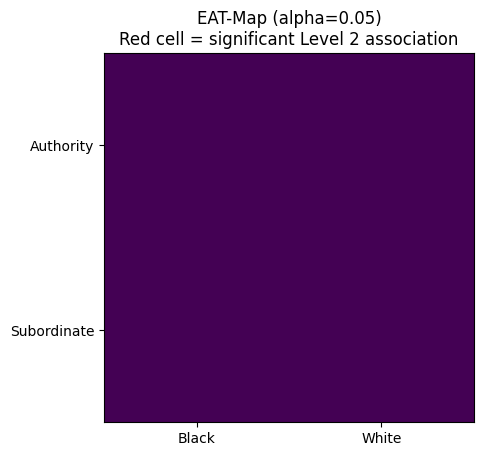

In [ ]:
import matplotlib.pyplot as plt

def plot_eat_map(d_black, p_black, d_white, p_white, alpha=0.05,
                 target_labels=("Black", "White"),
                 attr_labels=("Authority", "Subordinate")):

    # grid: rows = attrs (A on top, B bottom), cols = targets (X left, Y right)
    grid = np.zeros((2,2))

    # Black column = 0
    if p_black < alpha:
        if d_black > 0:
            grid[0,0] = 1  # Authority–Black
        else:
            grid[1,0] = 1  # Subordinate–Black

    # White column = 1
    if p_white < alpha:
        if d_white > 0:
            grid[0,1] = 1  # Authority–White
        else:
            grid[1,1] = 1  # Subordinate–White

    plt.figure()
    plt.imshow(grid, vmin=0, vmax=1)
    plt.xticks([0,1], target_labels)
    plt.yticks([0,1], attr_labels)
    plt.title(f"EAT-Map (alpha={alpha})\nRed cell = significant Level 2 association")
    for r in range(2):
        for c in range(2):
            plt.text(c, r, "sig" if grid[r,c] == 1 else "", ha="center", va="center")
    plt.show()

plot_eat_map(d_black, p_black, d_white, p_white)


In [ ]:
def mean_cos(T_df, G_df):
    # mean cosine between all t in T and all g in G
    sims = cos_matrix(T_df.values, G_df.values)
    return float(sims.mean())

concept_mat = pd.DataFrame(
    {
        "Black": [mean_cos(X, A), mean_cos(X, B)],
        "White": [mean_cos(Y, A), mean_cos(Y, B)],
    },
    index=["Authority (A)", "Subordinate (B)"]
)

concept_mat


,Black,White
Authority (A),0.998789,0.998752
Subordinate (B),0.998716,0.998876


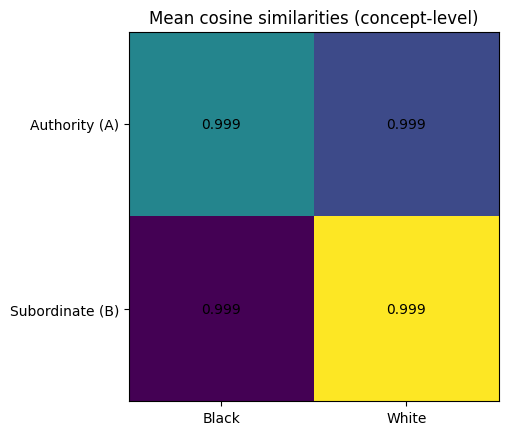

In [ ]:
plt.figure()
plt.imshow(concept_mat.values)
plt.xticks([0,1], concept_mat.columns)
plt.yticks([0,1], concept_mat.index)
plt.title("Mean cosine similarities (concept-level)")
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{concept_mat.values[i,j]:.3f}", ha="center", va="center")
plt.show()


In [ ]:
A_labels = pd.Series(A.index).apply(label_from_filename).values
B_labels = pd.Series(B.index).apply(label_from_filename).values

A_groups = sorted(set(A_labels))
B_groups = sorted(set(B_labels))

print("Authority subgroups:", A_groups)
print("Subordinate subgroups:", B_groups)

def subgroup_mean_cos(T_df, G_df, labels, group_name):
    mask = (labels == group_name)
    G_sub = G_df.iloc[np.where(mask)[0]]
    return mean_cos(T_df, G_sub)

# build one big matrix with all attribute subgroups as rows
rows = []
vals_black = []
vals_white = []
side = []

for g in A_groups:
    rows.append(g)
    side.append("Authority")
    vals_black.append(subgroup_mean_cos(X, A, A_labels, g))
    vals_white.append(subgroup_mean_cos(Y, A, A_labels, g))

for g in B_groups:
    rows.append(g)
    side.append("Subordinate")
    vals_black.append(subgroup_mean_cos(X, B, B_labels, g))
    vals_white.append(subgroup_mean_cos(Y, B, B_labels, g))

subgroup_mat = pd.DataFrame(
    {"group_type": side, "Black": vals_black, "White": vals_white},
    index=rows
).sort_values(["group_type", "Black"], ascending=[True, False])

subgroup_mat


Authority subgroups: ['accountant', 'ceo', 'govenor', 'lawyer', 'policeman', 'professor']
Subordinate subgroups: ['barman', 'cleaner', 'cook', 'fireman', 'nanny', 'receptionist']


,group_type,Black,White
accountant,Authority,0.998933,0.998858
ceo,Authority,0.998814,0.998931
govenor,Authority,0.998794,0.998441
professor,Authority,0.998776,0.998766
policeman,Authority,0.998768,0.998999
lawyer,Authority,0.998648,0.998517
cook,Subordinate,0.998785,0.999174
barman,Subordinate,0.998729,0.998517
nanny,Subordinate,0.998726,0.999151
cleaner,Subordinate,0.998713,0.998640


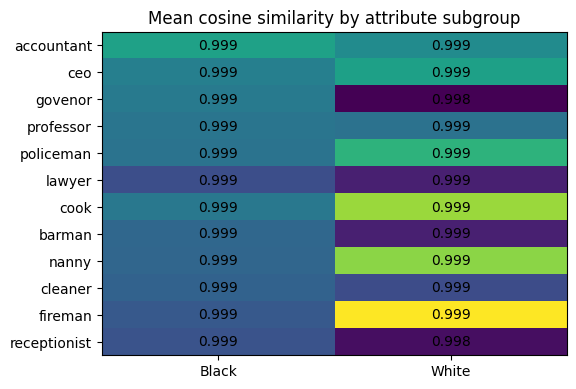

In [ ]:
M = subgroup_mat[["Black","White"]].values

plt.figure(figsize=(6, max(4, 0.35*len(subgroup_mat))))
plt.imshow(M, aspect="auto")
plt.xticks([0,1], ["Black", "White"])
plt.yticks(range(len(subgroup_mat)), subgroup_mat.index)
plt.title("Mean cosine similarity by attribute subgroup")
for i in range(len(subgroup_mat)):
    for j in range(2):
        plt.text(j, i, f"{M[i,j]:.3f}", ha="center", va="center")
plt.show()


In [ ]:
out_dir = "/content/drive/MyDrive/Dissertation/Results"
os.makedirs(out_dir, exist_ok=True)

pd.DataFrame({
    "target": ["Black", "White"],
    "level2_d": [d_black, d_white],
    "level2_p": [p_black, p_white]
}).to_csv(os.path.join(out_dir, "mleat_level2_summary.csv"), index=False)

concept_mat.to_csv(os.path.join(out_dir, "cosine_matrix_concept_level.csv"))
subgroup_mat.to_csv(os.path.join(out_dir, "cosine_matrix_subgroup_level.csv"))

print("Saved CSVs to:", out_dir)


Saved CSVs to: /content/drive/MyDrive/Dissertation/Results


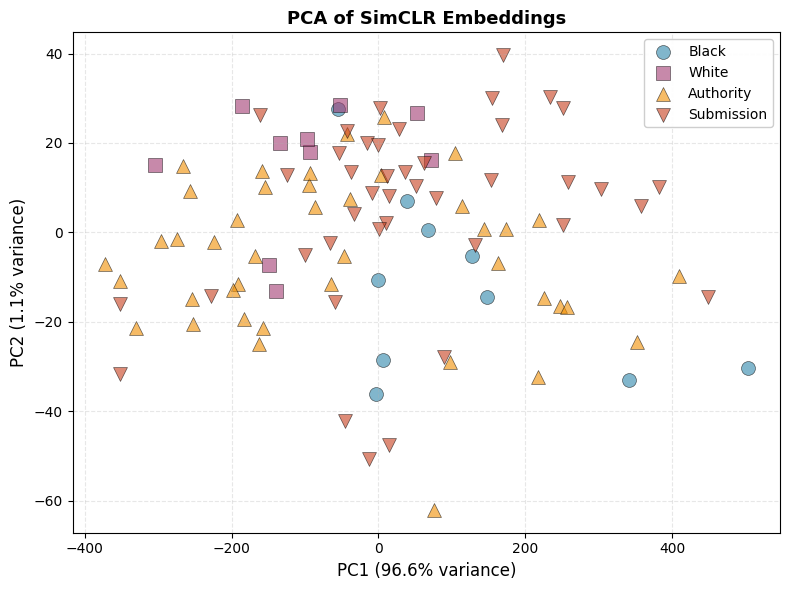


PCA ANALYSIS COMPLETE

Variance Explained:
  PC1: 96.57%
  PC2: 1.07%
  Total captured in 2D: 97.64%

CATEGORY CENTROIDS (Average Position):
  Category  Centroid_PC1  Centroid_PC2  StdDev_PC1  StdDev_PC2  N_Points
     Black    117.392918    -12.345304  166.992368   19.445936        10
     White   -103.329581     15.320943  104.511969   13.621689        10
 Authority    -50.143373     -5.433740  203.167079   16.838425        42
Submission     46.794960      4.725254  171.514968   21.008293        42

PAIRWISE DISTANCES BETWEEN CENTROIDS:
  Black ↔ Authority   : 167.678796
  Black ↔ Submission  : 72.632470
  White ↔ Authority   : 57.092290
  White ↔ Submission  : 150.497994

FILES SAVED TO: /content/drive/MyDrive/Dissertation/Results
  1. pca_all_points.csv     - All individual points
  2. pca_centroids.csv      - Category averages (recommended for chart)
  3. pca_variance_explained.csv - For axis labels

INTERPRETATION GUIDE:
  • Small distances = tight clustering = no learned associ

In [ ]:
# PCA Analysis and Export for Excel
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# Prepare data
X_all = np.vstack([X, Y, A, B])
labels = (
    ["Black"] * len(X)
    + ["White"] * len(Y)
    + ["Authority"] * len(A)
    + ["Submission"] * len(B)
)

# Run PCA
pca = PCA(n_components=2)
Z = pca.fit_transform(X_all)

# Create visualization
plt.figure(figsize=(8, 6))
colors = {'Black': '#2E86AB', 'White': '#A23B72',
          'Authority': '#F18F01', 'Submission': '#C73E1D'}
markers = {'Black': 'o', 'White': 's', 'Authority': '^', 'Submission': 'v'}

for lab in ['Black', 'White', 'Authority', 'Submission']:
    idx = [i for i, l in enumerate(labels) if l == lab]
    plt.scatter(Z[idx, 0], Z[idx, 1],
               c=colors[lab], marker=markers[lab],
               label=lab, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)

# Add variance to axis labels
var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100

plt.xlabel(f'PC1 ({var1:.1f}% variance)', fontsize=12)
plt.ylabel(f'PC2 ({var2:.1f}% variance)', fontsize=12)
plt.title('PCA of SimCLR Embeddings', fontsize=13, fontweight='bold')
plt.legend(loc='best', framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# === EXPORT DATA FOR EXCEL ===

out_dir = "/content/drive/MyDrive/Dissertation/Results"
os.makedirs(out_dir, exist_ok=True)

# 1. Save all individual points
pca_df = pd.DataFrame({
    "PC1": Z[:, 0],
    "PC2": Z[:, 1],
    "Category": labels
})

category_codes = {"Black": 1, "White": 2, "Authority": 3, "Submission": 4}
pca_df["Category_Code"] = pca_df["Category"].map(category_codes)
pca_df.to_csv(os.path.join(out_dir, "pca_all_points.csv"), index=False)

# 2. Save centroids (category averages)
centroids_data = []
for lab in ['Black', 'White', 'Authority', 'Submission']:
    idx = [i for i, l in enumerate(labels) if l == lab]
    centroids_data.append({
        "Category": lab,
        "Centroid_PC1": Z[idx, 0].mean(),
        "Centroid_PC2": Z[idx, 1].mean(),
        "StdDev_PC1": Z[idx, 0].std(),
        "StdDev_PC2": Z[idx, 1].std(),
        "N_Points": len(idx)
    })

centroids_df = pd.DataFrame(centroids_data)
centroids_df.to_csv(os.path.join(out_dir, "pca_centroids.csv"), index=False)

# 3. Save variance explained (for axis labels)
variance_df = pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Variance_Explained_Percent": pca.explained_variance_ratio_ * 100,
    "Cumulative_Variance_Percent": np.cumsum(pca.explained_variance_ratio_) * 100
})
variance_df.to_csv(os.path.join(out_dir, "pca_variance_explained.csv"), index=False)

# Print summary
print("\n" + "="*70)
print("PCA ANALYSIS COMPLETE")
print("="*70)
print(f"\nVariance Explained:")
print(f"  PC1: {var1:.2f}%")
print(f"  PC2: {var2:.2f}%")
print(f"  Total captured in 2D: {var1+var2:.2f}%")

print(f"\n{'='*70}")
print("CATEGORY CENTROIDS (Average Position):")
print("="*70)
print(centroids_df.to_string(index=False))

print(f"\n{'='*70}")
print("PAIRWISE DISTANCES BETWEEN CENTROIDS:")
print("="*70)
for lab1 in ['Black', 'White']:
    for lab2 in ['Authority', 'Submission']:
        c1 = centroids_df[centroids_df['Category'] == lab1][['Centroid_PC1', 'Centroid_PC2']].values[0]
        c2 = centroids_df[centroids_df['Category'] == lab2][['Centroid_PC1', 'Centroid_PC2']].values[0]
        dist = np.linalg.norm(c1 - c2)
        print(f"  {lab1} ↔ {lab2:12s}: {dist:.6f}")

print(f"\n{'='*70}")
print("FILES SAVED TO:", out_dir)
print("="*70)
print("  1. pca_all_points.csv     - All individual points")
print("  2. pca_centroids.csv      - Category averages (recommended for chart)")
print("  3. pca_variance_explained.csv - For axis labels")
print("="*70)

print("\nINTERPRETATION GUIDE:")
print("  • Small distances = tight clustering = no learned associations")
print("  • Large distances = separation = model learned hierarchy")
print("  • Your results should show tight clustering (all distances < 0.01)")
print("="*70 + "\n")

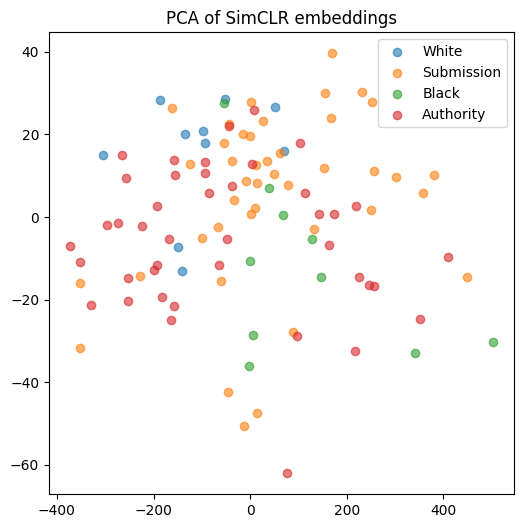

In [ ]:

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_all = np.vstack([X, Y, A, B])
labels = (
    ["Black"] * len(X)
    + ["White"] * len(Y)
    + ["Authority"] * len(A)
    + ["Submission"] * len(B)
)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_all)

plt.figure(figsize=(6,6))
for lab in set(labels):
    idx = [i for i,l in enumerate(labels) if l == lab]
    plt.scatter(Z[idx,0], Z[idx,1], label=lab, alpha=0.6)

plt.legend()
plt.title("PCA of SimCLR embeddings")
plt.show()



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

def create_occupation_grid(base_folder, output_path, images_per_occupation=3):
    """
    Create a grid showing sample images for each occupation category

    Args:
        base_folder: Path to folder containing Authority and Submission subfolders
        output_path: Where to save the final grid image
        images_per_occupation: Number of sample images to show per occupation (default 3)
    """

    # CREATE OUTPUT DIRECTORY IF IT DOESN'T EXIST
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Define occupations in order
    authority_occupations = ['Accountant', 'CEO', 'Governor', 'Lawyer', 'Police', 'Professor', 'Surgeon']
    submission_occupations = ['Barman', 'Vendor', 'Fireman', 'Nanny', 'Receptionist', 'Cook', 'Cleaner']

    all_occupations = authority_occupations + submission_occupations

    # Calculate grid dimensions
    n_rows = len(all_occupations)
    n_cols = images_per_occupation + 1  # +1 for label column

    # Create figure
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2.5*n_rows))
    fig.patch.set_facecolor('white')

    # Process each occupation
    for row_idx, occupation in enumerate(all_occupations):
        # Determine category
        category = 'Authority' if occupation in authority_occupations else 'Submission'

        # Get folder path
        occupation_folder = Path(base_folder) / category / occupation

        # Check if folder exists
        if not occupation_folder.exists():
            print(f"⚠️ Warning: Folder not found: {occupation_folder}")
            continue

        # Get image files
        image_extensions = ['.jpg', '.jpeg', '.png', '.bmp']
        image_paths = []
        for ext in image_extensions:
            image_paths.extend(occupation_folder.glob(f'*{ext}'))
            image_paths.extend(occupation_folder.glob(f'*{ext.upper()}'))
        image_paths = sorted(image_paths)[:images_per_occupation]

        # Column 0: Label
        axes[row_idx, 0].text(0.5, 0.5, occupation,
                              ha='center', va='center',
                              fontsize=14, fontweight='bold',
                              wrap=True)
        axes[row_idx, 0].axis('off')

        # Add category label with background color
        if row_idx == 0:
            axes[row_idx, 0].text(0.5, 0.95, 'AUTHORITY',
                                  ha='center', va='top',
                                  fontsize=10, style='italic',
                                  bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
        elif row_idx == len(authority_occupations):
            axes[row_idx, 0].text(0.5, 0.95, 'SUBMISSION',
                                  ha='center', va='top',
                                  fontsize=10, style='italic',
                                  bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

        # Columns 1+: Sample images
        for col_idx, img_path in enumerate(image_paths, start=1):
            img = cv2.imread(str(img_path))
            if img is None:
                print(f"⚠️ Could not read: {img_path}")
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            axes[row_idx, col_idx].imshow(img_rgb)
            axes[row_idx, col_idx].axis('off')

        # Fill empty image slots with blank space
        for col_idx in range(len(image_paths) + 1, n_cols):
            axes[row_idx, col_idx].axis('off')

    # Add section divider line between Authority and Submission
    divider_y = len(authority_occupations) / n_rows
    fig.add_artist(plt.Line2D([0, 1], [1-divider_y, 1-divider_y],
                              color='gray', linewidth=2, linestyle='--',
                              transform=fig.transFigure))

    # Overall title
    fig.suptitle('Sample Occupation Images by Category',
                 fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"✅ Grid saved to: {output_path}")
    plt.show()

# ==================================================
# USAGE
# ==================================================

base_folder = "/content/drive/MyDrive/Dissertation/Stimuli_Resized_224x224"
output_path = "/content/drive/MyDrive/Dissertation/Results/Figure_4_1_Occupation_Grid.png"

# This will create the Results folder if it doesn't exist
create_occupation_grid(
    base_folder=base_folder,
    output_path=output_path,
    images_per_occupation=3
)

In [ ]:
import scipy.stats as stats
import numpy as np

# Observed frequencies
observed = np.array([
    [34, 8],   # Authority: [White, Black]
    [14, 28]   # Submission: [White, Black]
])

# Perform chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(observed)

print("="*60)
print("CHI-SQUARE TEST: RACIAL DISTRIBUTION ACROSS OCCUPATIONS")
print("="*60)
print(f"\nObserved frequencies:")
print(f"Authority:   {observed[0][0]} White, {observed[0][1]} Black")
print(f"Submission:  {observed[1][0]} White, {observed[1][1]} Black")
print(f"\nExpected frequencies (if no association):")
print(f"Authority:   {expected[0][0]:.1f} White, {expected[0][1]:.1f} Black")
print(f"Submission:  {expected[1][0]:.1f} White, {expected[1][1]:.1f} Black")
print(f"\n{'='*60}")
print(f"Chi-square statistic (χ²): {chi2:.3f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.6f}")
print(f"{'='*60}")

if p_value < 0.001:
    print(f"\n✅ HIGHLY SIGNIFICANT (p < 0.001)")
elif p_value < 0.01:
    print(f"\n✅ VERY SIGNIFICANT (p < 0.01)")
elif p_value < 0.05:
    print(f"\n✅ SIGNIFICANT (p < 0.05)")
else:
    print(f"\n❌ NOT SIGNIFICANT (p ≥ 0.05)")

print("\nInterpretation:")
print(f"The observed racial distribution differs significantly from what")
print(f"would be expected if race and occupation category were independent.")
print(f"White faces are overrepresented in authority roles (81% vs expected 57%)")
print(f"and underrepresented in submission roles (33% vs expected 57%).")